# $\text{AR}(1)$ with Offset

$\text{AR}(1)$ with a constant offset is defined by,

$
\begin{equation}
X_t = \varphi X_{t-1} + \mu^* + \sigma \varepsilon_t
\end{equation}
\tag{1}
$

where, $\varepsilon \sim \text{Normal}(0,1)$

The stationarity requires $\lvert \varphi \rvert < 1$. The stationary mean and variance are given by,

$
\begin{align}
&\lim_{t \to \infty} \text{E}(X_t) = \frac{\mu^*}{1 - \varphi} \\
&\lim_{t \to \infty} \text{Var}(X_t) = \frac{\sigma^2}{1 - \varphi^2}
\end{align}
\tag{2}
$

It follows that $X_t$ has distribution,

$
\begin{align}
X_t \sim \text{Normal}\left(  \frac{\mu}{1 - \varphi} ,  \frac{\sigma^2}{1 - \varphi^2} \right)
\end{align}
\tag{3}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import stack, fcurve, PlotType, curve
from lib.data import arima, stats
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
σ = 1.0
nsample = 1000

def cumu_mean_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Mean to $t\\rightarrow\\infty$ Limit:  $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_mean = stats.compute_cumu_mean(t, ar)
    _, ar_mean = arima.compute_ar1_offset_mean(φ=φ, μ=μ, npts=len(t))
    fcurve(data=cumu_mean, func=ar_mean, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", r"$\mu_t\rightarrow \frac{\mu^*}{1 - \varphi}$"], title=title)
    
def cumu_sd_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Standard Deviation to $t\\rightarrow\\infty$ Limit: $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_sd = stats.compute_cumu_sd(t, ar)
    _, ar_sd = arima.compute_ar1_offset_sd(npts=len(t), φ=φ, σ=σ)
    fcurve(data=cumu_sd, func=ar_sd, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", r"$\sigma_t\rightarrow\sqrt{\frac{\sigma^2}{1-\varphi^2}}$"], title=title)
        
def comparison_plot_μ(μ_vals, ylim, title, *params):
    labels = [r"$μ^*=$" + f"{val}" for val in μ_vals]
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)
    
def comparison_plot_φ(φ_vals, ylim, title, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)


## Simulation $\varphi$ Scan

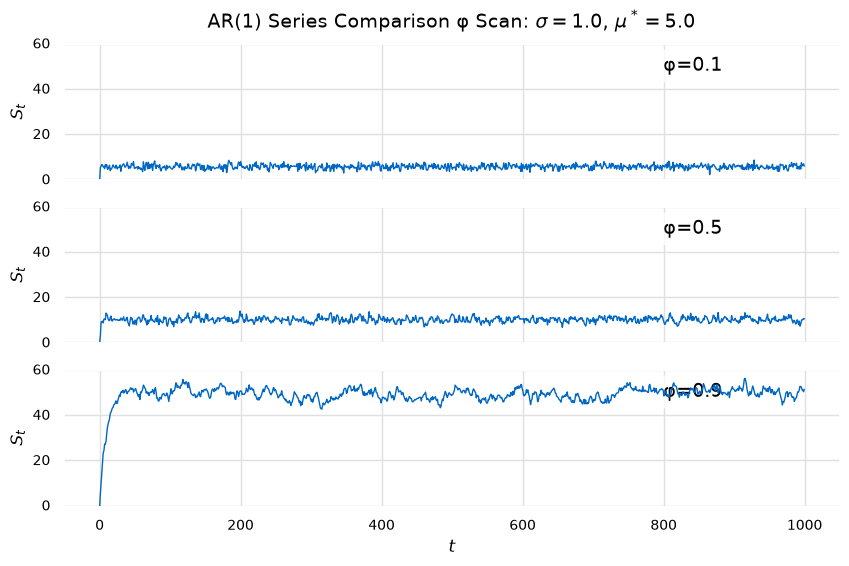

In [3]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: $σ={{{σ}}}$, $μ^*={{{μ}}}$"
φ_vals = [0.1, 0.5, 0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [0.0, 60.0], title, *params)

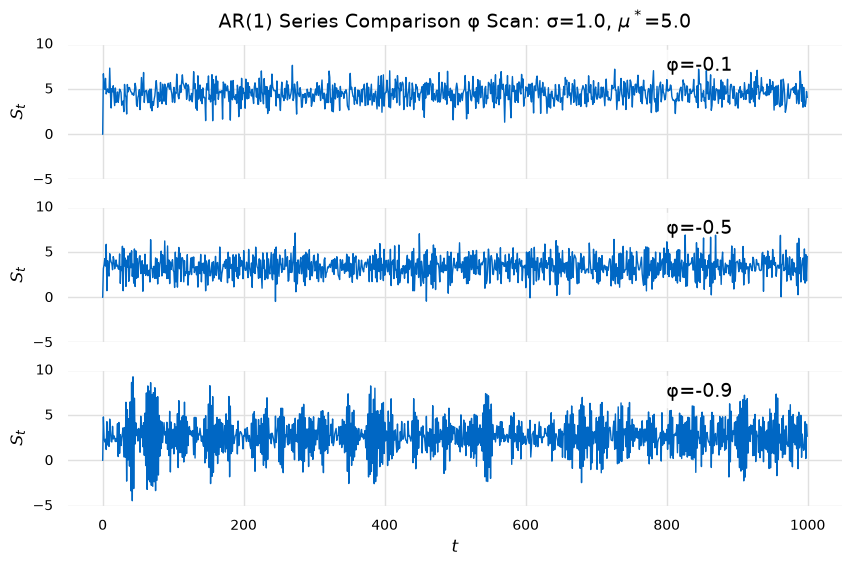

In [4]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: σ={σ}, " + r"$μ^*$=" + f"{μ}"
φ_vals = [-0.1, -0.5, -0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [-5.0, 10.0], title, *params)

## Simulation $\mu^*$ Scan

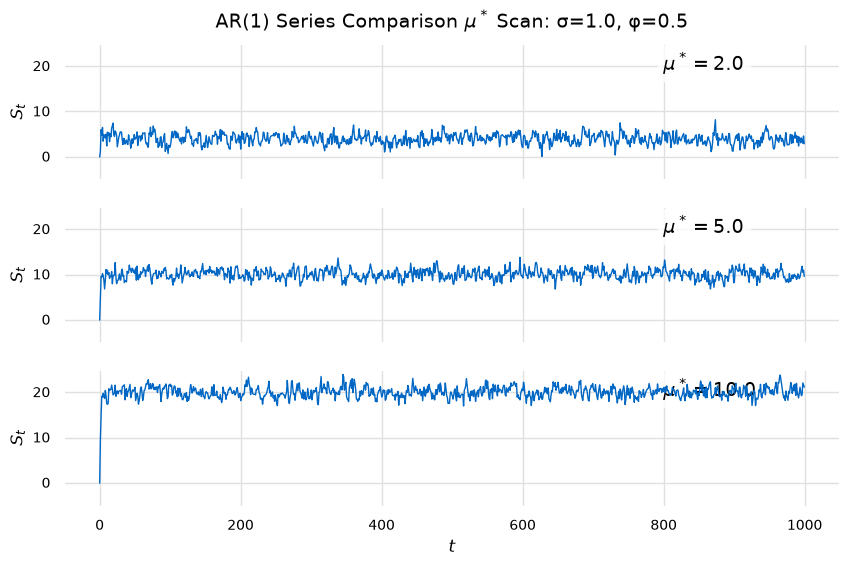

In [5]:
φ = 0.5
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [2.0, 5.0, 10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-5.0, 25.0], title, *params)

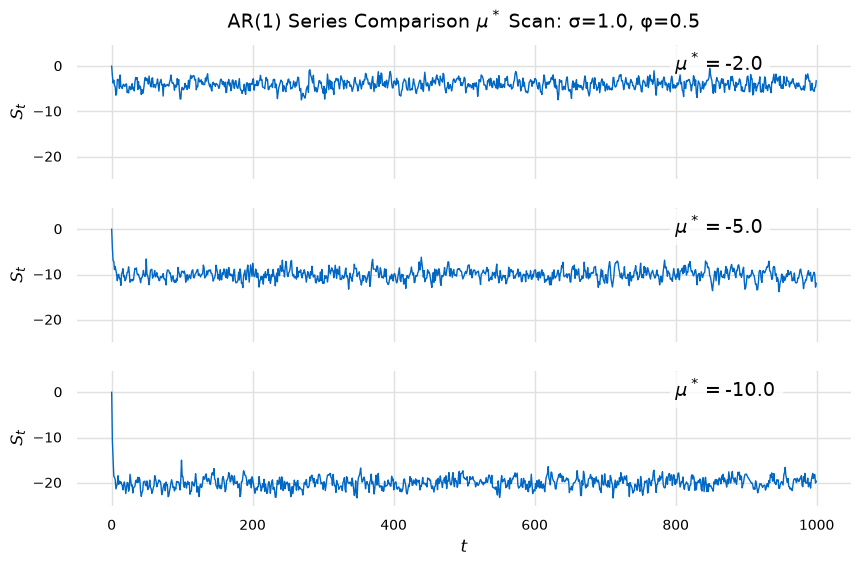

In [6]:
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [-2.0, -5.0, -10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-25.0, 5.0], title, *params)

## Mean

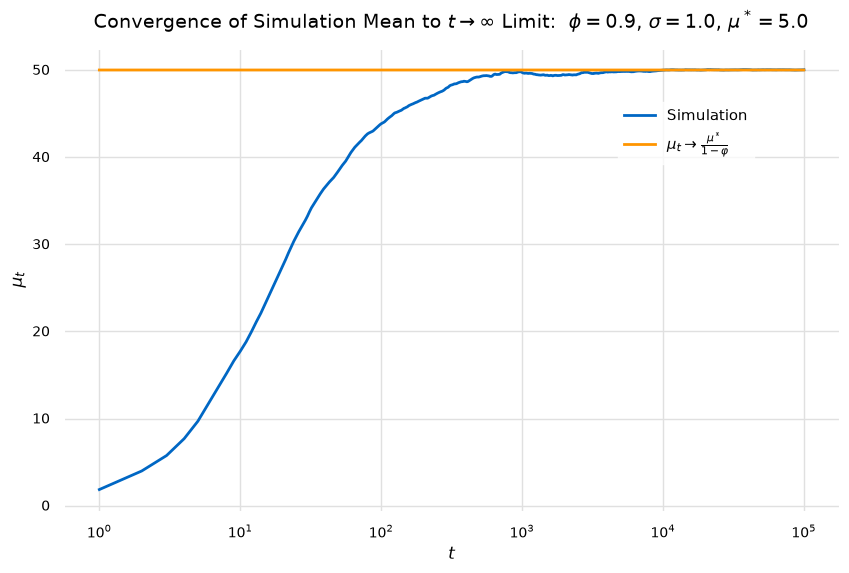

In [7]:
φ = 0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

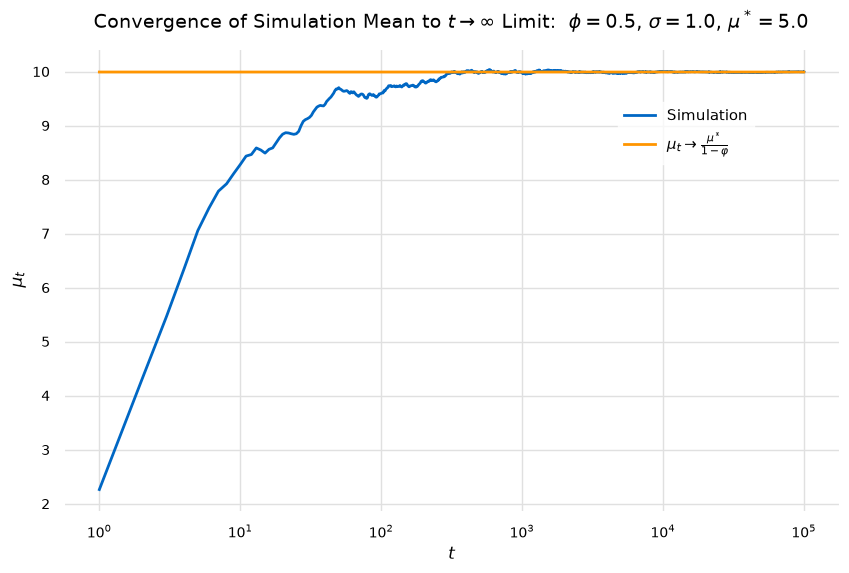

In [8]:
φ = 0.5
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

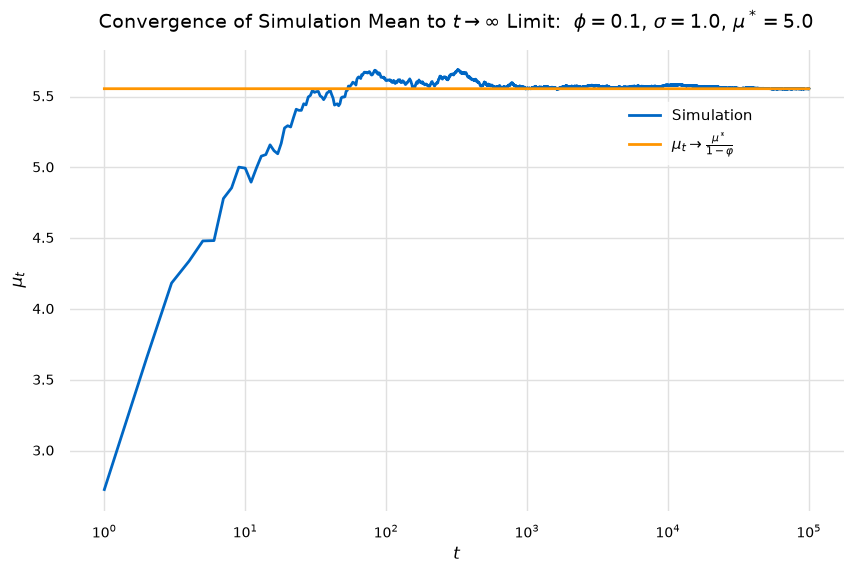

In [9]:
φ = 0.1
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

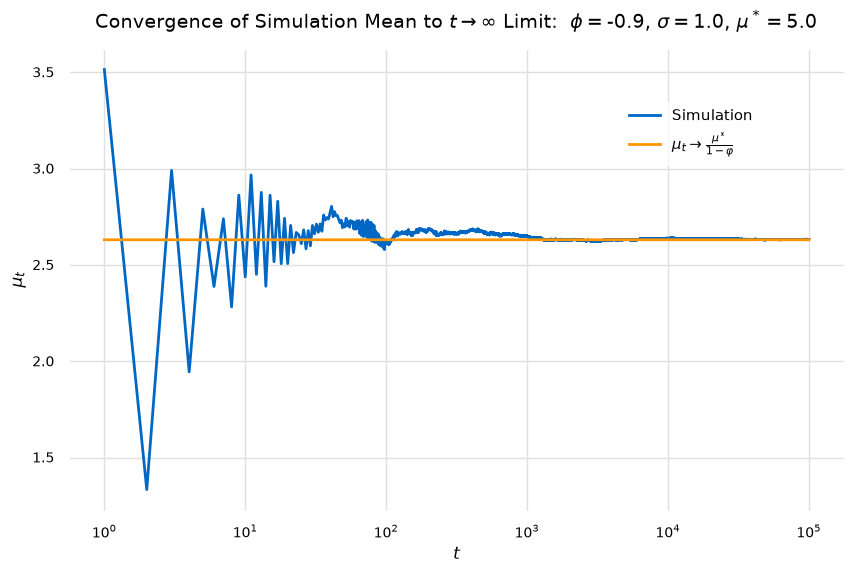

In [10]:
φ = -0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

## Standard Deviation

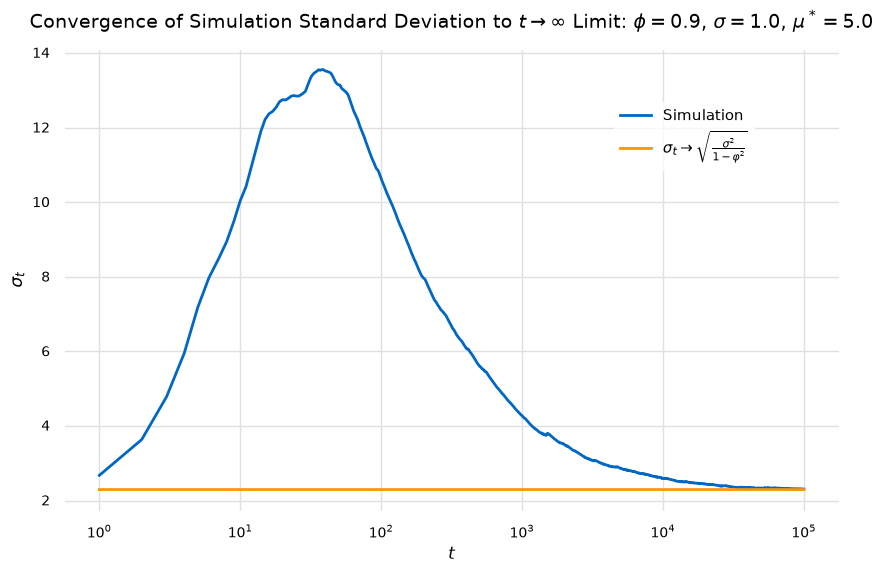

In [11]:
φ = 0.9
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

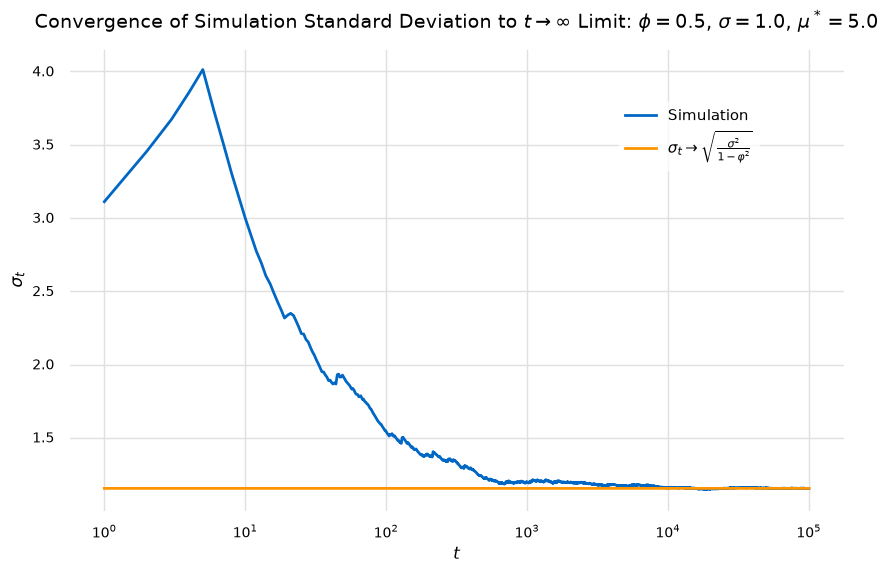

In [12]:
φ = 0.5
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

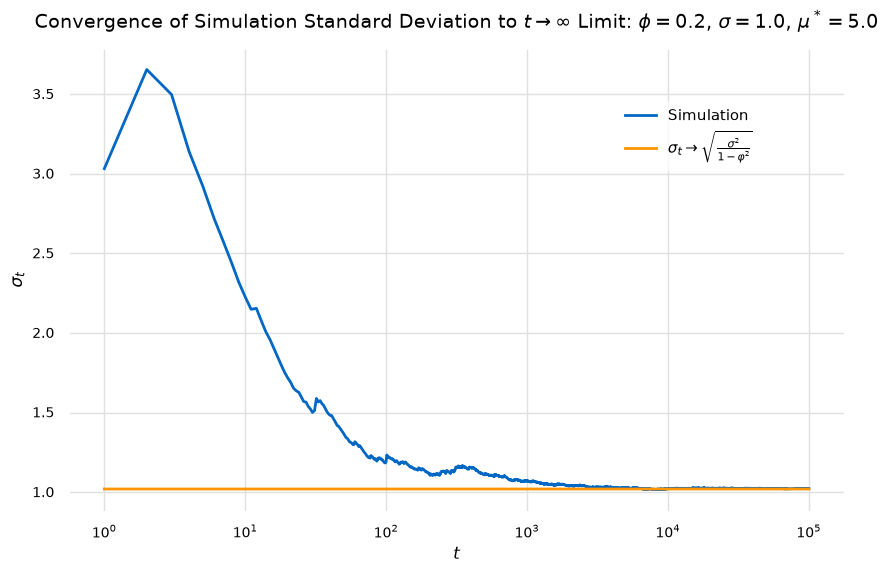

In [13]:
φ = 0.2
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

## Parameter Estimation

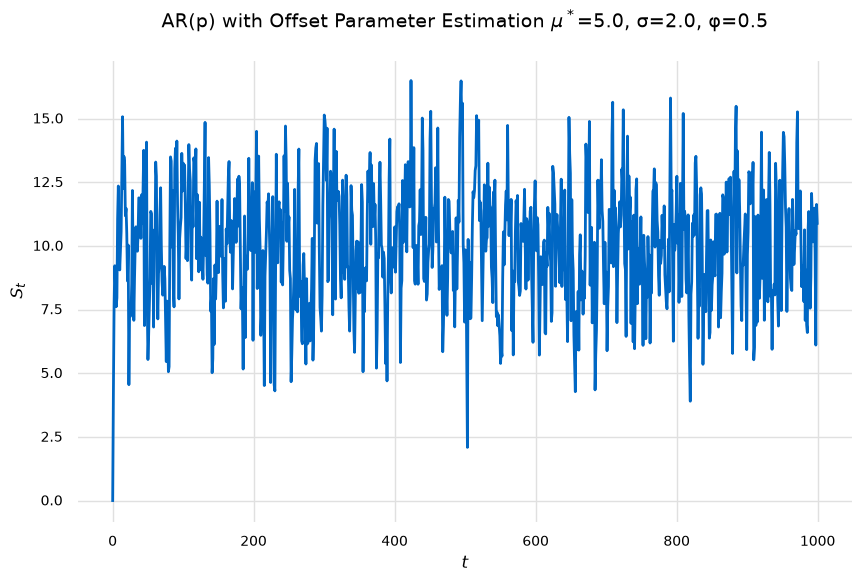

In [14]:
φ = 0.5
μ = 5.0
σ = 2.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [15]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2113.990
Date:                Sun, 30 Aug 2026   AIC                           4233.980
Time:                        10:54:55   BIC                           4248.703
Sample:                             0   HQIC                          4239.575
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0149      0.129     77.773      0.000       9.762      10.267
ar.L1          0.5080      0.026     19.892      0.000       0.458       0.558
sigma2         4.0140      0.179     22.379      0.000       3.662       4.366
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 9.36
Prob(Q):                              0.92   Prob(JB):                         0.01
Heteroskedasticity (H):               0.98   Skew:                            -0.23
Prob(H) (two-sided):                  0.87   Kurtosis:                         3.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 10.0148697104038,
      "err": 0.1287712386053958,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e433c77c-9907-4cc2-827f-eb1d2267e627",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.5079613269206479,
         "err": 0.025536127689164183,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e433c77c-9907-4cc2-827f-eb1d2267e627",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 4.014025019412951,
      "err": 0.17936950762929418,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "es

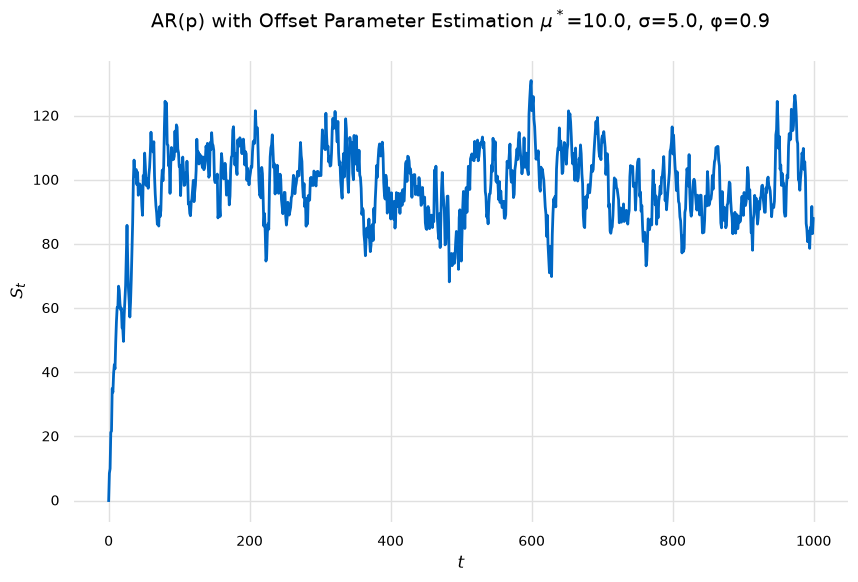

In [17]:
φ = 0.9
μ = 10.0
σ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [18]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3038.331
Date:                Sun, 30 Aug 2026   AIC                           6082.663
Time:                        10:54:55   BIC                           6097.386
Sample:                             0   HQIC                          6088.259
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.3402      3.284     29.031      0.000      88.903     101.777
ar.L1          0.9536      0.005    204.867      0.000       0.945       0.963
sigma2        25.4411      1.097     23.194      0.000      23.291      27.591
===================================================================================
Ljung-Box (L1) (Q):                   1.46   Jarque-Bera (JB):                42.38
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.07
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 95.3402165118582,
      "err": 3.284136859047135,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5dd7f1bd-7b11-4c0c-8a85-cef21bbb691f",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.953638744167856,
         "err": 0.004654914091191761,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "5dd7f1bd-7b11-4c0c-8a85-cef21bbb691f",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.4410909851148,
      "err": 1.0968809222944933,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id

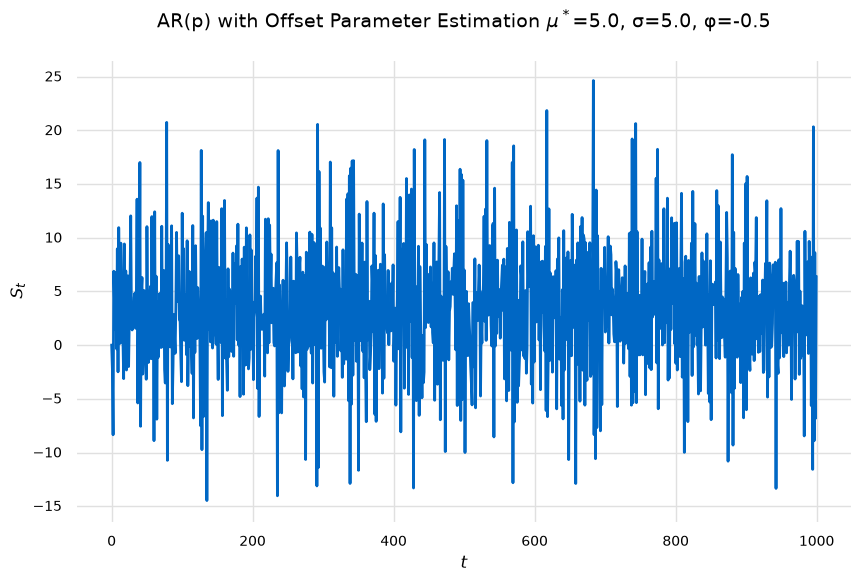

In [20]:
φ = -0.5
μ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [21]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3050.373
Date:                Sun, 30 Aug 2026   AIC                           6106.745
Time:                        10:54:56   BIC                           6121.469
Sample:                             0   HQIC                          6112.341
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3479      0.107     31.238      0.000       3.138       3.558
ar.L1         -0.5128      0.028    -18.281      0.000      -0.568      -0.458
sigma2        26.1163      1.048     24.917      0.000      24.062      28.171
===================================================================================
Ljung-Box (L1) (Q):                   1.33   Jarque-Bera (JB):                10.24
Prob(Q):                              0.25   Prob(JB):                         0.01
Heteroskedasticity (H):               0.99   Skew:                             0.04
Prob(H) (two-sided):                  0.90   Kurtosis:                         3.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "trend": "c",
   "const": {
      "est": 3.3478686899860417,
      "err": 0.10717252808106456,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "d00545fa-be62-4b78-9393-727fba7915cc",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": -0.5128311927430983,
         "err": 0.028053307212105152,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "d00545fa-be62-4b78-9393-727fba7915cc",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 26.11631511987703,
      "err": 1.0481325681208333,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      